In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.dates as mdates

from datetime import date
from dateutil.relativedelta import relativedelta

In [28]:
df = pd.read_csv("https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv")

In [29]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [30]:
df['Month'] = pd.to_datetime(df['Month']) #convert to datetime
df = df.set_index('Month')

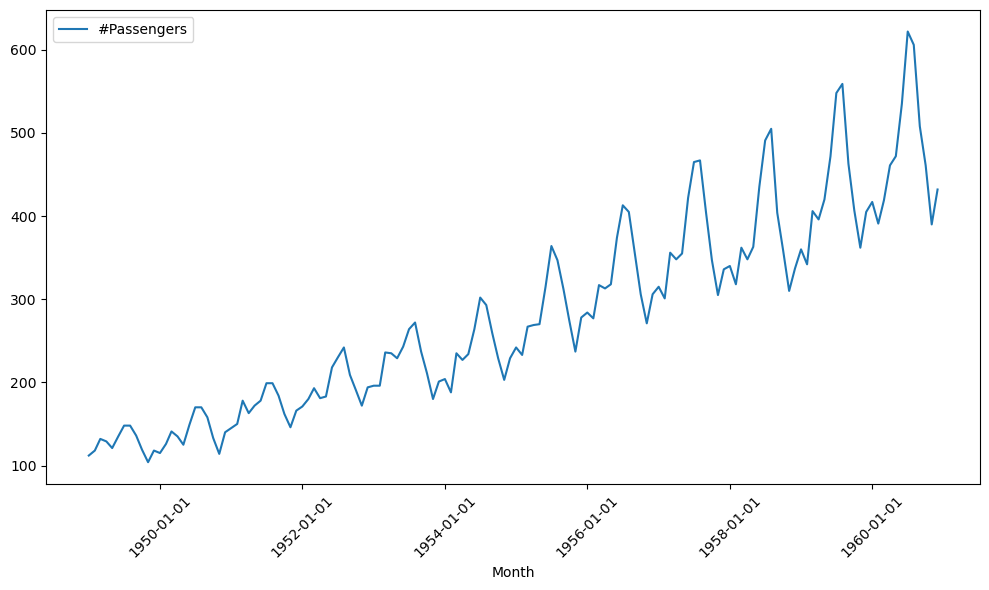

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df, ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Identify if there is a seasonality first:

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

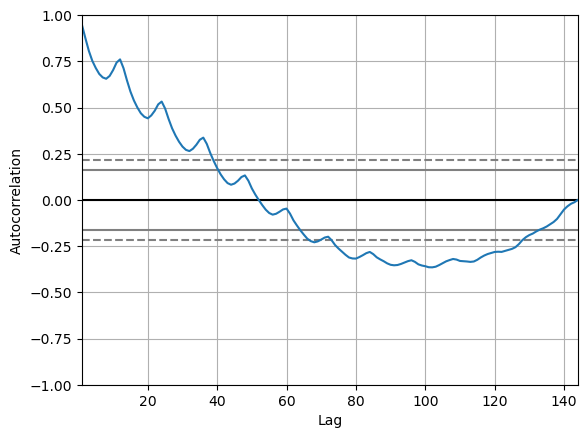

In [32]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['#Passengers'])

Considering the above, it looks like there is a seasonality that repeats every 12 lags or so. Lets identify the ACF and PACF:

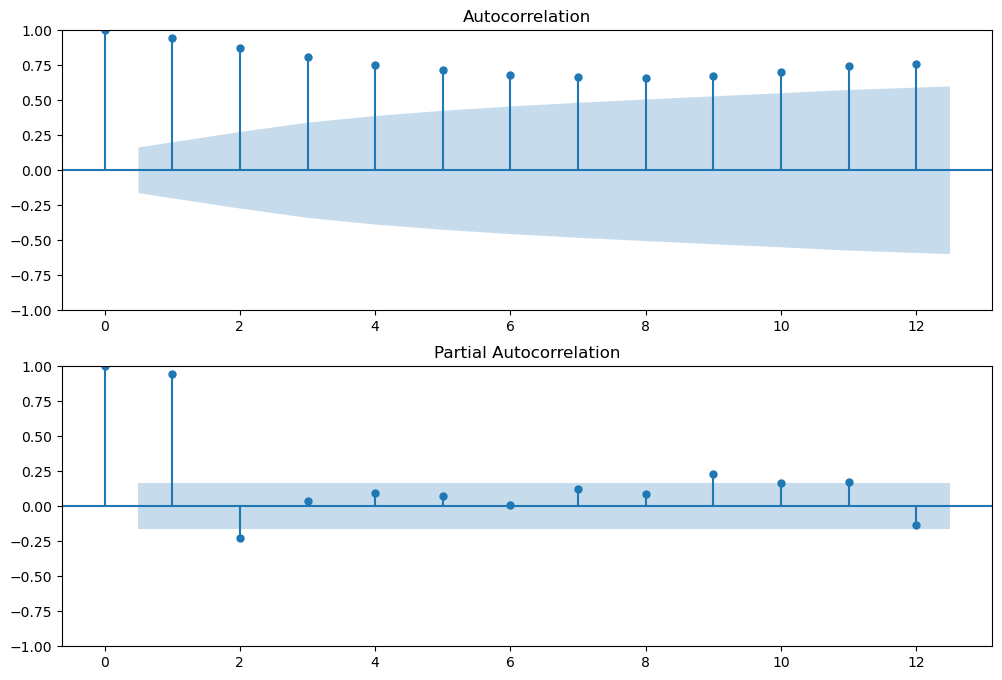

In [33]:
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['#Passengers'], lags=12, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['#Passengers'], lags=12, ax=ax2)

ACF plots show the correlation between a time series and a lagged version of itself, decreasing exponentially. 

PACF plots show the correlation between a time series and a lagged version of itself after removing the effects of intervening observations. The PACF graph is abrupt after 2 views.

the next thing we need to do es identify the decomposition parts:

<Figure size 640x480 with 0 Axes>

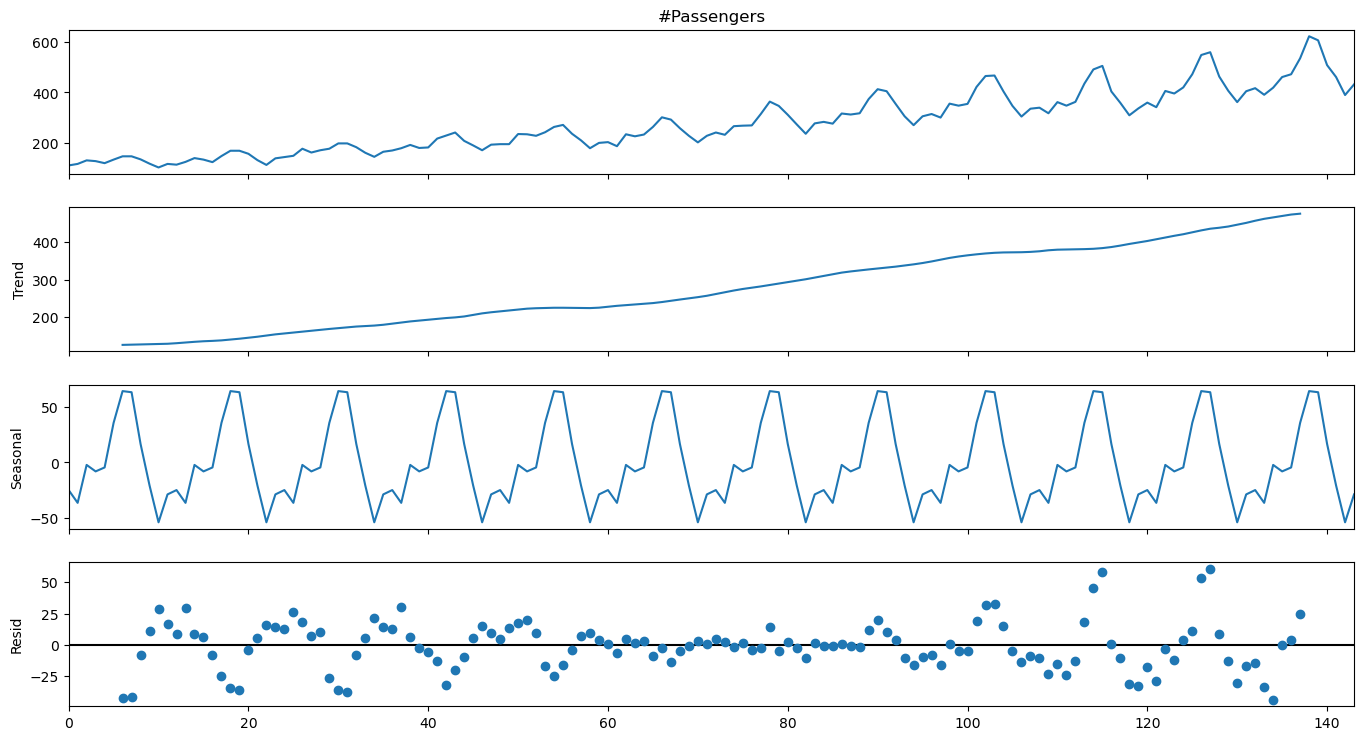

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['#Passengers'], period=12)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(15, 8)

In [34]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=52).mean()
    rolstd = timeseries.rolling(window=52).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 8))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

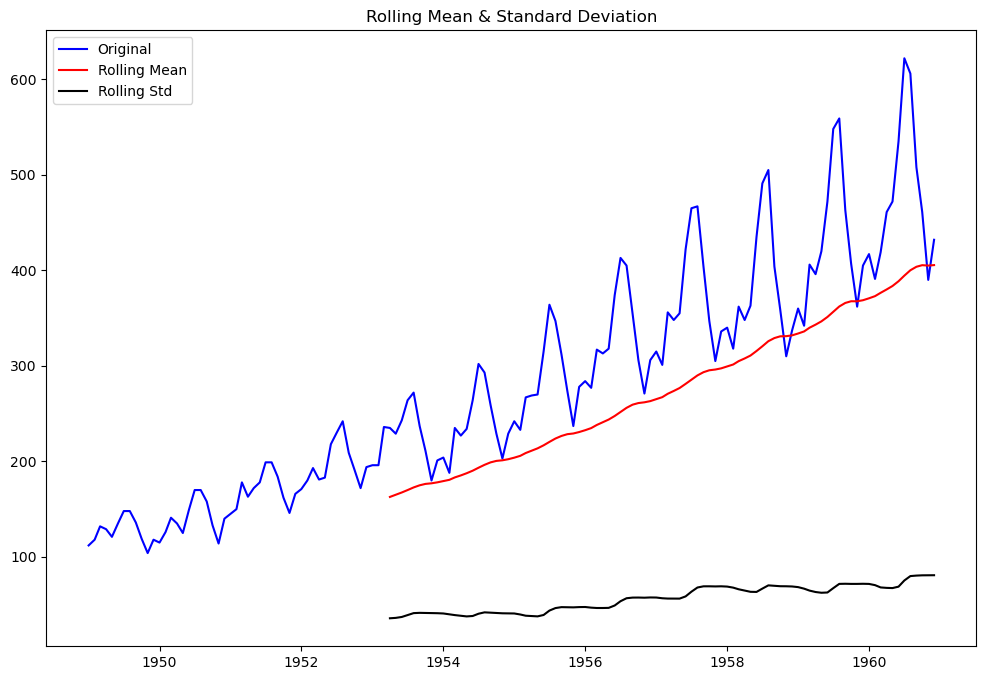

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [35]:
test_stationarity(df['#Passengers'])

Since the results are showing the data is not stationary, we need to make it stationary by either differencing, log, square, cube root or proportional change

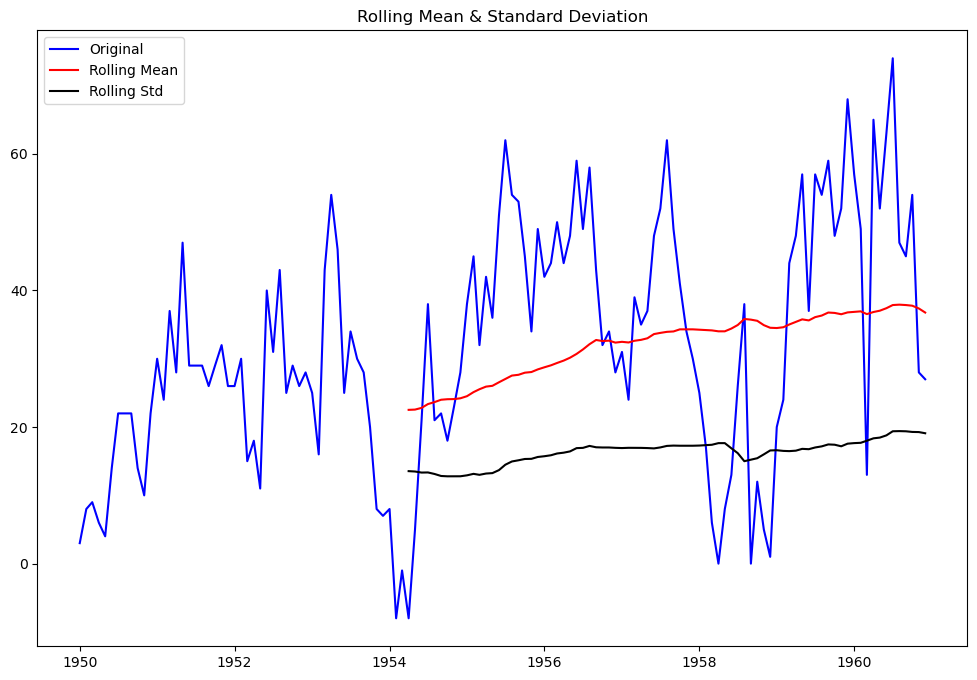

Results of Dickey-Fuller Test:
Test Statistic                  -3.383021
p-value                          0.011551
#Lags Used                       1.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [36]:
df_firstdiff = df['#Passengers'].diff(12) #taking the first difference
test_stationarity(df_firstdiff.dropna()) #testing the data to identify if it is stationary now

Now that the data is stationary, we can identify the p, d and q values to use for ARIMa. in order to do so we are going to use auto ARIMA

In [39]:
df['month_index']= df.index.month

In [41]:
import pmdarima as pmd

model=pmd.auto_arima(df['#Passengers'], exogenous = df['month_index'], 
                        start_p=1, start_q=1, test='adf',
                        max_p=3, max_q=3, m=12,
                        start_P=0, seasonal=True,
                        d=None, D=1, trace=True, error_action='ignore',
                        suppress_warnings=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.33 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.14 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.23 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.34 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.74 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.50 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.62 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.51 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.57 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.38 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.13 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.47 sec
 ARIMA(0,1,1)(1,1,1)[12]     

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Sun, 15 Feb 2026   AIC                           1019.178
Time:                                     13:04:47   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

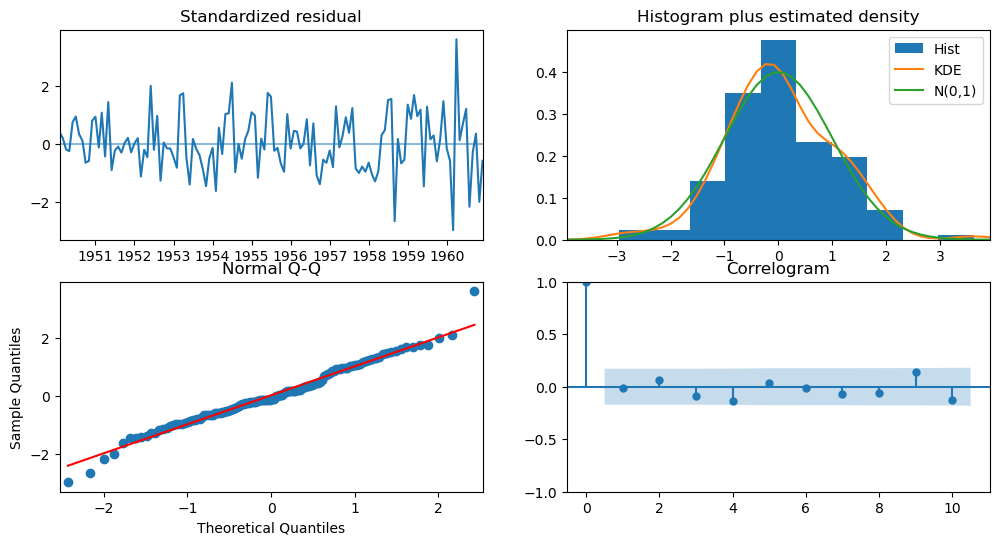

In [42]:
display(model.summary())
model.plot_diagnostics(figsize=(12,6));

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
mod=SARIMAX(df['#Passengers'],order=(0,1,1),seasonal_order=(2,1,0,12))
sarima = mod.fit()
predicted=sarima.predict();predicted

C:\Users\Alfredo.Hernandez\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Alfredo.Hernandez\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


1949-01-01      0.000000
1949-02-01    111.997178
1949-03-01    117.999698
1949-04-01    131.999295
1949-05-01    129.000151
                 ...    
1960-08-01    630.591419
1960-09-01    511.058149
1960-10-01    456.766670
1960-11-01    412.628553
1960-12-01    438.478198
Freq: MS, Name: predicted_mean, Length: 144, dtype: float64

We are looking for: 
<ul>
    <li>P > |z| (p-value) < 0.05</li>
    <li>Prob(Q) > 0.05 --> residues are white noise</li>
    <li>Prob(JB) > 0.05 residues normally distributed</li>
    <li>Prob(H) > 0.05 variance of residuals is constant over time</li>
</ul>


In [44]:
df['pred'] = predicted

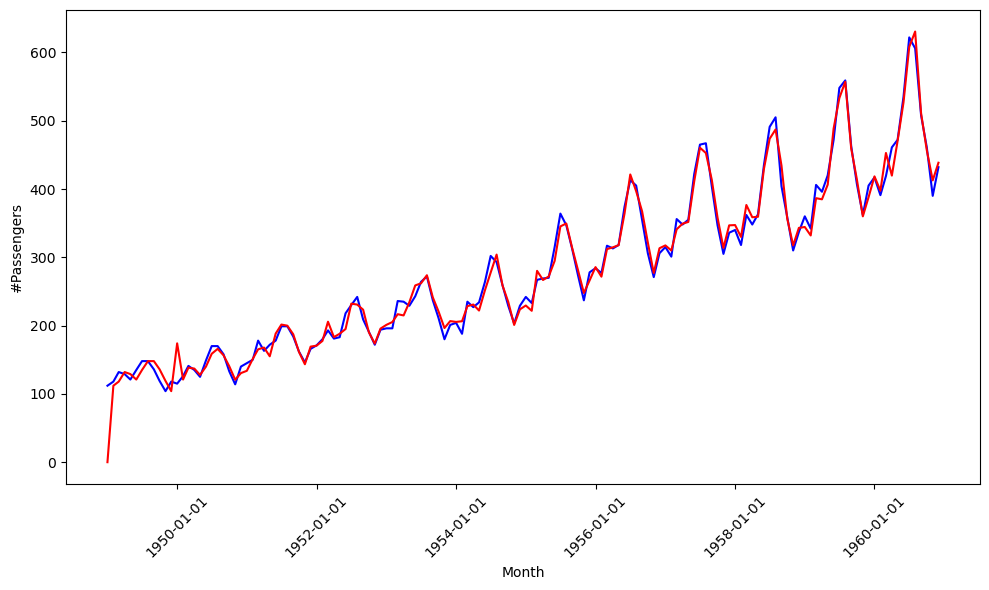

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df, x='Month', y='#Passengers', ax=ax, color='blue')
sns.lineplot(df, x='Month', y='pred', ax=ax, color='red')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Now, for future forecast. we will create the funciton that takes the trained model and generates 2 years (24 months) of forecast:

In [84]:
def sarimax_forecast(SARIMAX_model, periods=24):
    # Forecast
    n_periods = periods

    forecast_df = pd.DataFrame({"month_index": pd.date_range(df.index[-1], periods=n_periods, freq='MS').month},
                               index=pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS'))

    fcst = SARIMAX_model.get_forecast(steps=n_periods,
                                            exog=forecast_df['month_index'])
    fitted = fcst.predicted_mean
    confint = fcst.conf_int(alpha = 0.05)

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=fitted.index)
    lower_series = pd.Series(confint.iloc[:, 0], index=confint.index)
    upper_series = pd.Series(confint.iloc[:, 1], index=confint.index)

    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(df["#Passengers"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                     lower_series,
                     upper_series,
                     color='k', alpha=.15)

    plt.title("SARIMAX - Forecast of Airline Passengers")
    plt.show()

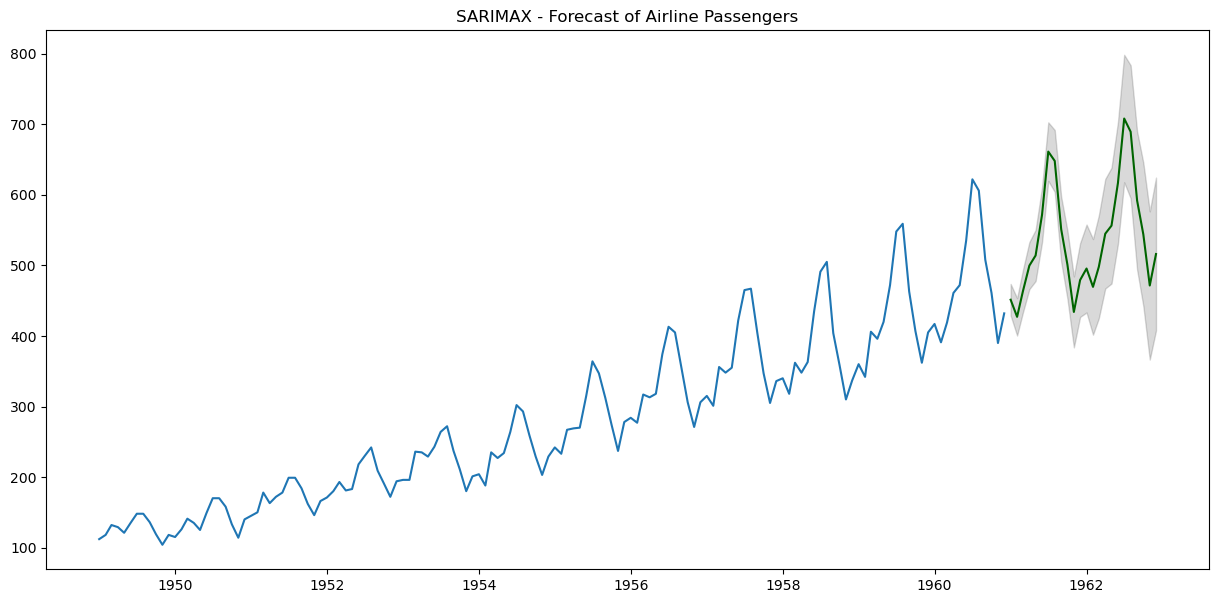

In [83]:
sarimax_forecast(sarima, 24)